# 04 — The Leveraged Bad-Market Strategy

**The hypothesis.** Bad (below-trend) periods are often followed by strong rebounds. So instead of going to *cash* when the market is below its moving average, what if we go to *leveraged* S&P 500 to capture a bigger recovery?

> Above the MA → hold **1x** S&P 500.
> Below the MA → hold **Lx** daily-leveraged S&P 500 (L = 1.25 … 3.0).

**Daily leverage** means each day's return is multiplied by L *and then compounded*: `strategy_return[t] = L * sp500_return[t]` when below the MA. Compounding daily is what creates **volatility decay** — we will see it bite here and study it properly in notebook 07.

**We do not assume it works.** We just measure it honestly.

In [1]:
# --- standard setup (run me first) ---
import sys, os
# Make the project root importable so `from src import ...` works from notebooks/.
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Setup complete. Project root:", os.path.abspath(".."))

Setup complete. Project root: C:\Users\Taffy Jackson\leveraged-trend-following


In [2]:
from src import data_loader as dl, returns as rt, backtest as bt
from src import metrics as mx, plots as pl, config

underlying, ticker, _ = dl.get_underlying_total_return()
u = rt.simple_returns(underlying)
rf = dl.get_risk_free_daily(u.index)

## Run all leverage levels at the 200-day window

In [3]:
rows = []; results = {}
for L in config.LEVERAGE_LEVELS:
    res = bt.leveraged_bad_market(underlying, u, 200, L, rf_daily=rf,
                                  costs=config.ZERO_COSTS)
    results[L] = res
    srow = res.summary(rf_daily=rf); srow['leverage'] = L
    rows.append(srow)
tbl = mx.summary_frame(rows)
tbl[['leverage','cagr','volatility','sharpe','max_drawdown','calmar']]

,leverage,cagr,volatility,sharpe,max_drawdown,calmar
0,1.0000,0.1142,0.1787,0.5370,-0.5525,0.2067
1,1.2500,0.1156,0.2052,0.4986,-0.6356,0.1819
2,1.5000,0.1157,0.2336,0.4653,-0.7070,0.1637
3,2.0000,0.1121,0.2937,0.4134,-0.8303,0.1350
4,2.5000,0.1034,0.3563,0.3764,-0.9151,0.1130
5,3.0000,0.0896,0.4204,0.3492,-0.9612,0.0932


**Read this table carefully.** As leverage rises, look at what happens to CAGR versus max drawdown. Typically CAGR barely improves (or even falls) while the drawdown gets *much* deeper and the Sharpe ratio *falls*. That is the first hint that the hypothesis is in trouble: the extra leverage is buying risk, not return.

## The equity curves and drawdowns

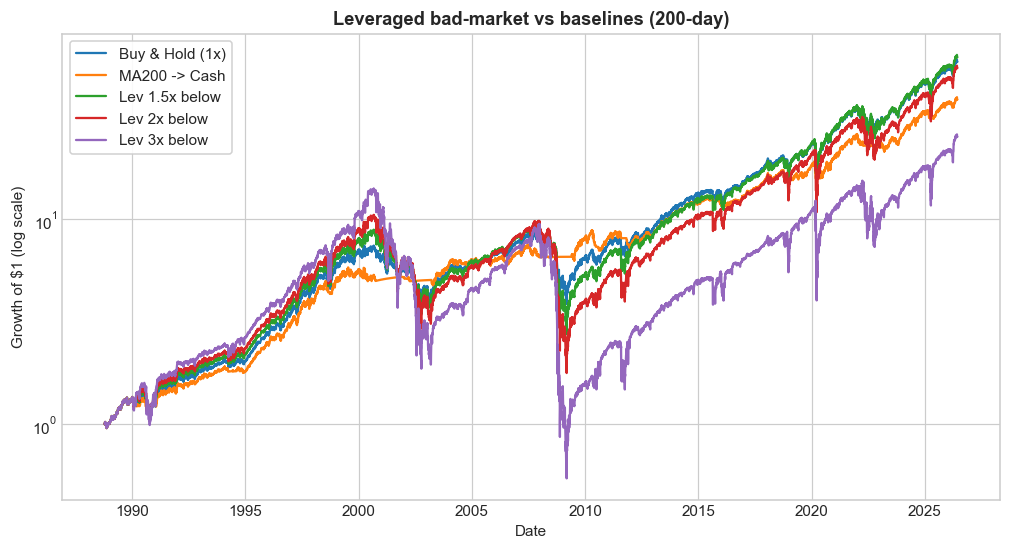

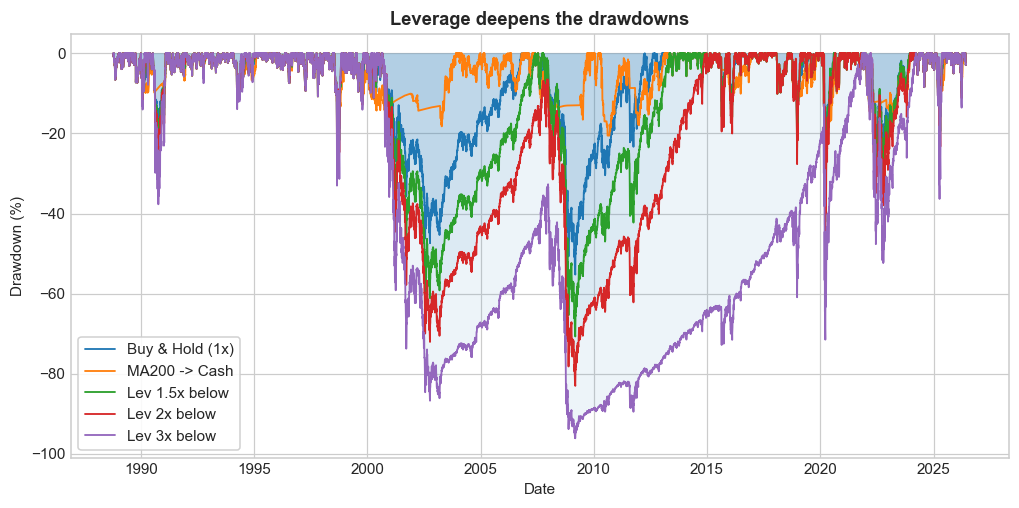

In [4]:
bh = bt.buy_and_hold(u, rf_daily=rf)
ma200 = bt.ma_to_cash(underlying, u, 200, rf_daily=rf)
comp = {'Buy & Hold (1x)': bh.net_returns, 'MA200 -> Cash': ma200.net_returns,
        'Lev 1.5x below': results[1.5].net_returns,
        'Lev 2x below': results[2.0].net_returns,
        'Lev 3x below': results[3.0].net_returns}
common = comp['Buy & Hold (1x)'].index
for v in comp.values(): common = common.intersection(v.index)
comp = {k: v.reindex(common).dropna() for k,v in comp.items()}
eq = {k: rt.cumulative_index(v) for k,v in comp.items()}
fig = pl.plot_equity_comparison(eq, 'Leveraged bad-market vs baselines (200-day)',
    '03_equity_leverage_levels_200d.png'); plt.show()
fig = pl.plot_drawdowns(comp, 'Leverage deepens the drawdowns',
    '03_drawdowns_leverage.png'); plt.show()

Watch the **3x** line: it can lead for years, then a single sustained bear (2000–02 or 2008–09) sends it down 90%+ and it never catches up. Leverage applied during *prolonged* declines compounds the losses — the opposite of the rebound we hoped for.

➡️ **Next:** notebook 05 sweeps *every* window × leverage combination and draws heatmaps, so we are not cherry-picking the 200-day case.